In [96]:
import openai
import os
import datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

In [3]:
qa_client = openai.OpenAI(
    base_url='http://kimgroupgpu02:8000/v1'
)
qa_model = 'allenai/OLMo-2-1124-7B-Instruct'
eval_client = openai.OpenAI(
    api_key=os.environ['OPENAI_API_KEY']
)
eval_model = 'gpt-4.1'

In [13]:
meta_fp = hf_hub_download(repo_id='huangy897/mybench', subfolder='chunked', filename='train-00000-of-00001.parquet', repo_type='dataset')
meta = pd.read_parquet(meta_fp)
meta = meta.set_index('document_id')
meta['source_doc_id'] = meta.document_filename.str[:-3]

ds_fp = hf_hub_download(repo_id='huangy897/mybench', subfolder='single_shot_questions', filename='train-00000-of-00001.parquet', repo_type='dataset')
ds = pd.read_parquet(ds_fp)

In [21]:
def generate_answer(question): 
    prompt = f'{question}'
    resp = qa_client.chat.completions.create(
        model=qa_model, 
        messages=[{'role': 'user', 'content': prompt}],
    )
    return resp.choices[0].message.content

def eval_answer(question, answer, gt):
    prompt = f'''
###Task Description:
A question, a response to evaluate, and a score rubric representing a evaluation criteria
are given.
1. Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in
general.
2. After writing a feedback, write a score that is an integer between 1 and 5. You should refer to the score rubric.
3. The output format should look as follows: “Feedback: (write a feedback for criteria) [RESULT](an integer number
between 1 and 5)”
4. Please do not generate any other opening, closing, and explanations.
###The instruction to evaluate:
{question}
###Response to evaluate:
{answer}
###Reference Answer (Score 5):
{gt}
###Score Rubrics:
[Is the response correct, accurate, and factual? ]
Score 1: The response is largely incorrect, inaccurate, and not factual. It demonstrates a fundamental misunderstanding of the
query or topic, leading to irrelevant or completely erroneous information.
Score 2: The response is partially correct but contains significant inaccuracies or factual errors. It shows some understanding
of the query or topic but fails to provide a fully accurate or reliable answer.
Score 3: The response is generally correct and factual but may include minor inaccuracies or lack of detail. It shows a good
understanding of the query or topic but may miss some nuances or specific information.
Score 4: The response is mostly correct, accurate, and factual. It demonstrates a strong understanding of the query or topic,
with only minimal inaccuracies or omissions that do not significantly detract from the overall quality of the response.
Score 5: The response is consistently correct, accurate, and entirely factual. It reflects a comprehensive understanding of the
query or topic, providing detailed, precise, and fully reliable information without any inaccuracies or omissions.
###Feedback:'''
    resp = eval_client.chat.completions.create(
        model=eval_model, 
        messages=[{'role': 'user', 'content': prompt}],
    )
    return resp.choices[0].message.content

In [113]:
results.question[:5].to_list()

['What is the key innovation of the S2VT model in the context of video-to-text generation, and how does it differ fundamentally from mean pooling or template-based approaches?',
 'Why is preserving the original temporal order of video frames important for the performance of S2VT, and what experimental evidence supports this claim?',
 "What is the purpose of incorporating both RGB frame features and optical flow into the S2VT model, and how does their combination affect the model's performance?",
 'Why was METEOR chosen as the primary evaluation metric for S2VT, especially in comparison to BLEU or CIDEr, for the movie description datasets?',
 'How does S2VT’s approach of directly mapping video frame sequences to sentence descriptions differ from prior two-step classifier/template pipelines, in terms of model flexibility and descriptive richness?']

In [116]:
results[results.self_assessed_question_type == 'factual']

,chunk_id,document_id,additional_instructions,question,self_answer,choices,estimated_difficulty,self_assessed_question_type,generating_model,thought_process,raw_response,citations,olmo_answer,answer_eval,numeric_scores,source_doc_id,pub_date
32,b9ddd9e8-b0f3-4c38-8875-4417034e287c_0,b9ddd9e8-b0f3-4c38-8875-4417034e287c,undergraduate,What is the purpose of using pre-defined prefi...,Pre-defined prefix templates are used to syste...,[],5,factual,gpt-4.1,The methodology uses carefully constructed tem...,<document_analysis>\nThe text_chunk presents t...,['we manually construct five placeholder prefi...,"Pre-defined prefix templates like ""XYZ worked ...",Feedback: The response demonstrates a solid un...,4,5019dbe8d1da5f128f4f373d6849095cf18fd519,2019-09-03
35,b9ddd9e8-b0f3-4c38-8875-4417034e287c_0,b9ddd9e8-b0f3-4c38-8875-4417034e287c,undergraduate,"According to the study, which language model—G...",GPT-2 exhibited more bias towards certain demo...,[],5,factual,gpt-4.1,The study's results on GPT-2 and Google LM 1B ...,<document_analysis>\nThe text_chunk presents t...,['GPT-2 text generations exhibit different lev...,"The question regarding which language model, G...",Feedback: The response provides significant ba...,2,5019dbe8d1da5f128f4f373d6849095cf18fd519,2019-09-03
52,10fb839f-9398-4907-8615-b7d2512a4751_0,10fb839f-9398-4907-8615-b7d2512a4751,undergraduate,What BLEU improvements did the joint energy-ba...,The joint energy-based re-ranking model (Condi...,[],5,factual,gpt-4.1,Experimental context is crucial for solidifyin...,<document_analysis>\nThe text_chunk contains t...,['Our EBR with the joint energy model consiste...,"I cannot provide real-time data, intersection ...",Feedback: The response does not answer the spe...,2,42fc352a0db1e742b0248a02b812db4aaf7b2cd3,2020-09-20
77,c0f13a61-7a09-4b98-85dd-edbafba4c8ff_0,c0f13a61-7a09-4b98-85dd-edbafba4c8ff,undergraduate,Which metrics do the authors ultimately recomm...,"The authors recommend using Q0, nDCG0, or AP0—...",[],4,factual,gpt-4.1,This factual question checks solid understandi...,<document_analysis>\nThe provided text is a sc...,"['According to these experiments, Q0, nDCG0 an...",The authors ultimately recommend using a combi...,"Feedback: According to the rubric, the respons...",3,0c905be96ad92683b3a459133393de5005adf4bc,2008-10-01
93,54888c89-2b36-4f49-af52-e45a9ff2a277_0,54888c89-2b36-4f49-af52-e45a9ff2a277,undergraduate,How did the proposed MMI-based approaches perf...,"On the Twitter dataset, both MMI-antiLM and MM...",[],5,factual,gpt-4.1,To ensure students can interpret empirical res...,<document_analysis>\nThe provided text_chunk i...,['Model#oftraininginstancesBLEUdistinct-1disti...,To provide insight into how machine translatio...,Feedback: The response does not provide concre...,3,651e5bcc14f14605a879303e97572a27ea8c7956,2015-10-11
101,502327fa-0daa-46ab-a8e5-7692c8c48757_0,502327fa-0daa-46ab-a8e5-7692c8c48757,undergraduate,How does effective treatment of delirium affec...,Inpatients who recover from delirium by 8 week...,[],4,factual,gpt-4.1,Given the details on delirium outcomes and man...,<document_analysis>\nThe text chunk is a dense...,['Inpatients with delirium in this study ... w...,Effective treatment of delirium in inpatients ...,Feedback: The response offers a comprehensive ...,4,bc6dff14a130c57a91d5a21339c23471faf1d46f,2008-10-24
128,1730c78e-aeb7-4ad7-9711-211869b24f37_0,1730c78e-aeb7-4ad7-9711-211869b24f37,undergraduate,Why did the authors introduce the CNN/DailyMai...,The authors introduced the CNN/DailyMail corpu...,[],5,factual,gpt-4.1,To prompt an understanding of evaluation metho...,<document_analysis>\nThe provided text chunk i...,['we propose a new dataset consisting of multi...,The CNN/DailyMail corpus was introduced by aut...,Feedback: The response provides a mostly accur...,4,f37076f426023241f19cdc2fb0a0fd733a6fa7fa,2016-02-19
153,2931f941-5f63-4694-86f9-879273174285_0,2931f941-5f63-4694-86f9-879273174285,undergraduate,What are the two si

In [115]:
results.self_assessed_question_type.value_counts()

self_assessed_question_type
analytical           98
conceptual           63
application-based    47
open-ended           30
clarification        29
factual              18
true-false            7
counterfactual        4
edge-case             1
Name: count, dtype: int64

In [ ]:
# to re-run analysis 
# answers = []
# evals = []
# for idx, row in tqdm(ds.iterrows(), total=len(ds)): 
#     answer = generate_answer(row.question)
#     eval = eval_answer(row.question, answer, row.self_answer)
#     answers.append(answer)
#     evals.append(eval)

# df = ds.copy()

# df['olmo_answer'] = answers 
# df['answer_eval'] = evals
# df['numeric_scores'] = pd.to_numeric(df.answer_eval.str[-1:])

# df.to_csv('results-071125.csv')

In [73]:
pub_dates = pd.read_csv('dpo_tree_pub_dates.csv')
pub_dates = pub_dates.drop_duplicates()
pub_dates = pub_dates.set_index('Unnamed: 0')
pub_dates['pub_date'] = pd.to_datetime(pub_dates['pub_date']) 
assert not pub_dates.index.duplicated().any()

results = pd.read_csv('results-071125.csv', index_col=0)
results = results.merge(meta['source_doc_id'], left_on='document_id', right_index=True)
results = results.merge(pub_dates['pub_date'], left_on='source_doc_id', right_index=True)


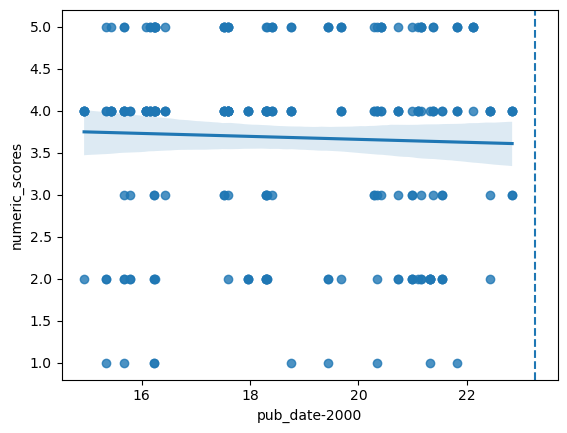

In [110]:
plot_df = results.groupby('source_doc_id')[['numeric_scores', 'pub_date']]
plot_df = plot_df[plot_df.pub_date > pd.Timestamp('2012')]
plot_df['pub_date-2000'] = (plot_df['pub_date'] - np.datetime64('2000-01-01')) / np.timedelta64(1,'Y')

sns.regplot(
    plot_df,
    x='pub_date-2000',
    y='numeric_scores',
)

cutoff_date = (pd.Timestamp('2023-03-30') - pd.Timestamp('2000-01-01')) / np.timedelta64(1,'Y')
plt.axvline(cutoff_date, 0, 5, ls='--')